# Code Appendix

This is the code appendix for Mathematical Modelling in Biology, Medicine and Public Health coursework 2.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate

In [ ]:
# load the data exported from XPP
data_sub = np.loadtxt('subthreshold.dat')
data_supra = np.loadtxt('suprathreshold.dat')
data_strong = np.loadtxt('strong_stim.dat')

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
C:\Users\nadia\AppData\Local\Temp\ipykernel_30384\1062265306.py:6: SyntaxWarning: invalid escape sequence '\m'
  (data_sub, 'A. Subthreshold Response ($I_{stim} = 35 \mu A/cm^2$)'),
C:\Users\nadia\AppData\Local\Temp\ipykernel_30384\1062265306.py:7: SyntaxWarning: invalid escape sequence '\m'
  (data_supra, 'B. Just Suprathreshold Response ($I_{stim} = 45 \mu A/cm^2$)'),
C:\Users\nadia\AppData\Local\Temp\ipykernel_30384\1062265306.py:8: SyntaxWarning: invalid escape sequence '\m'
  (data_strong, 'C. Strong Stimulation ($I_{stim} = 80 \mu A/cm^2$)')


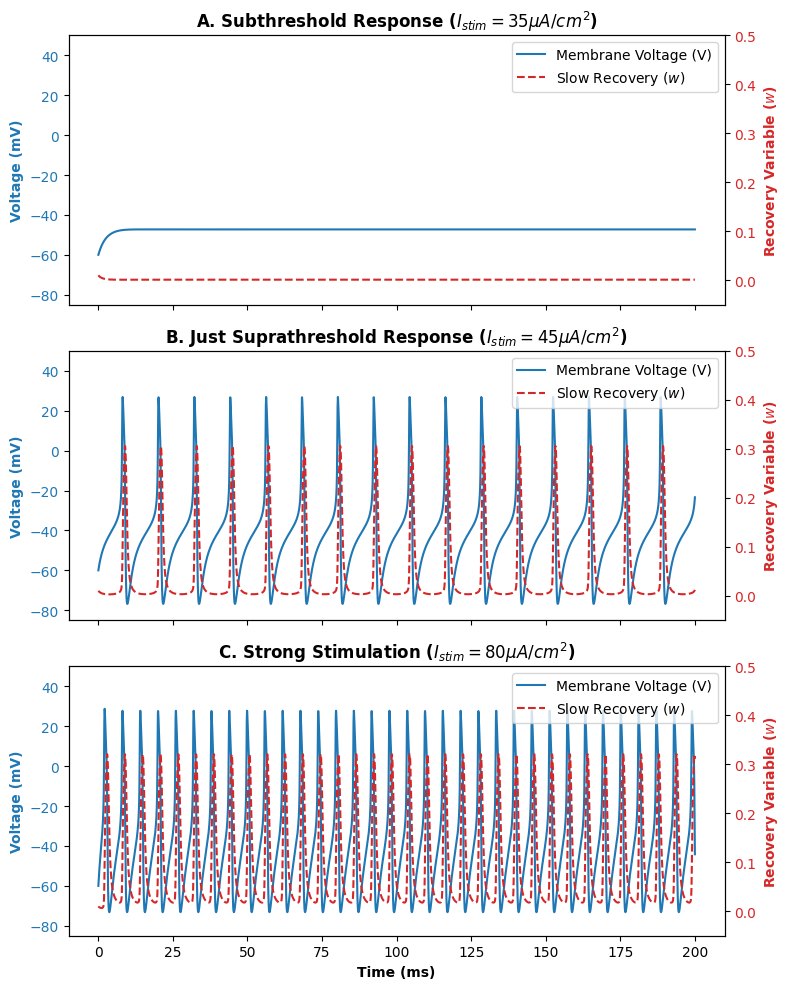

In [ ]:
# set up figure with 3 stacked subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

scenarios = [
    (data_sub, 'A. Subthreshold Response ($I_{stim} = 35 \mu A/cm^2$)'),
    (data_supra, 'B. Just Suprathreshold Response ($I_{stim} = 45 \mu A/cm^2$)'),
    (data_strong, 'C. Strong Stimulation ($I_{stim} = 80 \mu A/cm^2$)')
]

# loop through each subplot and plot the data
for ax, (data, title) in zip(axes, scenarios):
    t = data[:, 0]
    V = data[:, 1]
    w = data[:, 2]
    
    # voltage (V) on left y-axis
    color_V = 'tab:blue'
    ax.set_ylabel('Voltage (mV)', color=color_V, fontweight='bold')
    line_V = ax.plot(t, V, color=color_V, label='Membrane Voltage (V)')
    ax.tick_params(axis='y', labelcolor=color_V)
    ax.set_title(title, fontweight='bold')
    
    # recovery variable (w) on right y-axis
    ax2 = ax.twinx()  
    color_w = 'tab:red'
    ax2.set_ylabel('Recovery Variable ($w$)', color=color_w, fontweight='bold')
    line_w = ax2.plot(t, w, color=color_w, linestyle='--', label='Slow Recovery ($w$)')
    ax2.tick_params(axis='y', labelcolor=color_w)
    
    # y-limits slightly wider than the data
    ax.set_ylim(-85, 50)
    ax2.set_ylim(-0.05, 0.5)
    
    # legend
    lines = line_V + line_w
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper right')

axes[-1].set_xlabel('Time (ms)', fontweight='bold')

plt.tight_layout()
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
C:\Users\nadia\AppData\Local\Temp\ipykernel_30384\1631762464.py:10: SyntaxWarning: invalid escape sequence '\p'
  (data_slow, 'A. Slower Recovery ($\phi_w = 0.10$, $I_{stim} = 45$)'),
C:\Users\nadia\AppData\Local\Temp\ipykernel_30384\1631762464.py:11: SyntaxWarning: invalid escape sequence '\p'
  (data_base, 'B. Baseline Recovery ($\phi_w = 0.15$, $I_{stim} = 45$)'),
C:\Users\nadia\AppData\Local\Temp\ipykernel_30384\1631762464.py:12: SyntaxWarning: invalid escape sequence '\p'
  (data_fast, 'C. Faster Recovery ($\phi_w = 0.25$, $I_{stim} = 45$)')


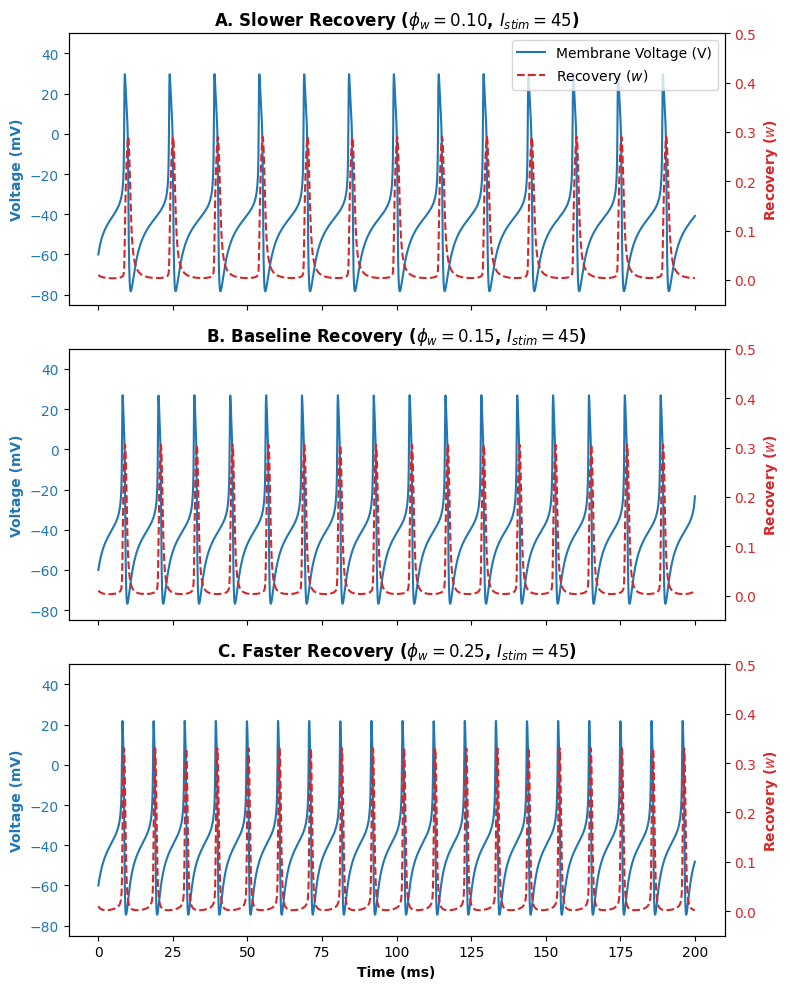

In [ ]:
# load data from XPP again
data_base = np.loadtxt('suprathreshold.dat')
data_fast = np.loadtxt('suprathreshold_fast_w.dat')
data_slow = np.loadtxt('suprathreshold_slow_w.dat')

# plot the 3 scenarios, similarly to above
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

scenarios = [
    (data_slow, 'A. Slower Recovery ($\phi_w = 0.10$, $I_{stim} = 45$)'),
    (data_base, 'B. Baseline Recovery ($\phi_w = 0.15$, $I_{stim} = 45$)'),
    (data_fast, 'C. Faster Recovery ($\phi_w = 0.25$, $I_{stim} = 45$)')
]

for ax, (data, title) in zip(axes, scenarios):
    t = data[:, 0]
    V = data[:, 1]
    w = data[:, 2]
    
    color_V = 'tab:blue'
    ax.set_ylabel('Voltage (mV)', color=color_V, fontweight='bold')
    line_V = ax.plot(t, V, color=color_V, label='Membrane Voltage (V)')
    ax.tick_params(axis='y', labelcolor=color_V)
    ax.set_title(title, fontweight='bold')
    
    ax2 = ax.twinx()  
    color_w = 'tab:red'
    ax2.set_ylabel('Recovery ($w$)', color=color_w, fontweight='bold')
    line_w = ax2.plot(t, w, color=color_w, linestyle='--', label='Recovery ($w$)')
    ax2.tick_params(axis='y', labelcolor=color_w)
    
    ax.set_ylim(-85, 50)
    ax2.set_ylim(-0.05, 0.5)

lines = line_V + line_w
labels = [l.get_label() for l in lines]
axes[0].legend(lines, labels, loc='upper right')
axes[-1].set_xlabel('Time (ms)', fontweight='bold')

plt.tight_layout()
plt.show()

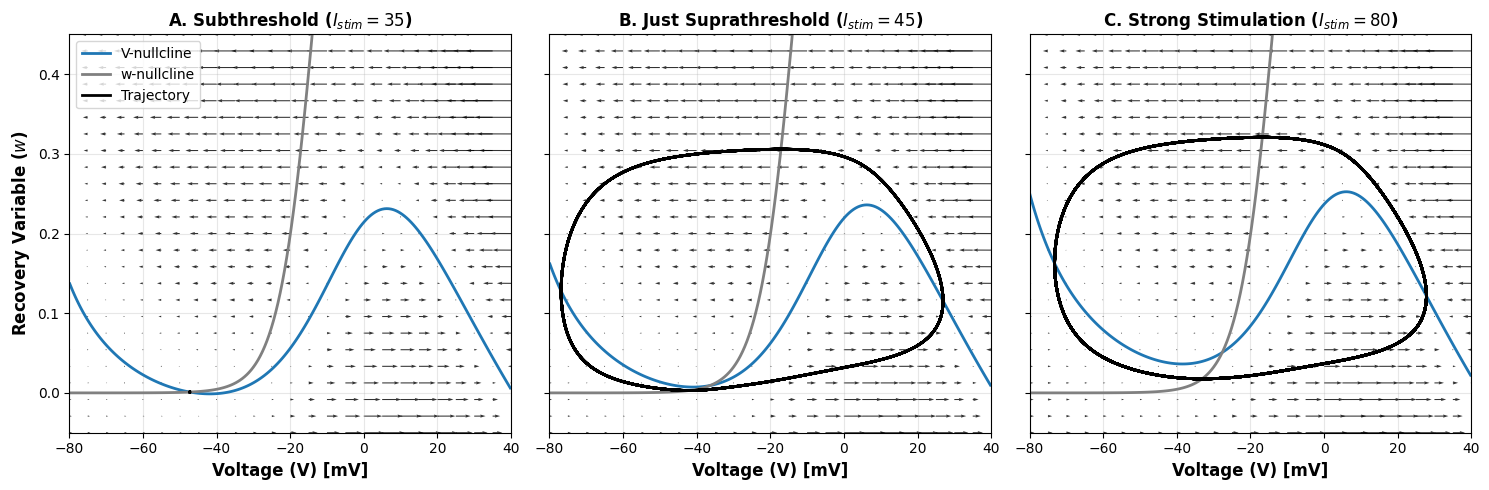

In [ ]:
def class2_model(t, x, Istim):
    V, w = x
    
    # model parameters and functions, as defined in .ode file read into XPP
    C = 2
    gfast = 20; ENa = 50; betam = -1.2; gammam = 18
    gslow = 20; EK = -100; betaw = -13; gammaw = 10
    gleak = 2; Eleak = -70
    phiw = 0.15

    minf = 0.5 * (1 + np.tanh((V - betam) / gammam))
    winf = 0.5 * (1 + np.tanh((V - betaw) / gammaw))
    tauw = 1 / np.cosh((V - betaw) / (2 * gammaw))

    Ifast = gfast * minf * (V - ENa)
    Islow = gslow * w * (V - EK)
    Ileak = gleak * (V - Eleak)

    V_dot = (Istim - Ifast - Islow - Ileak) / C
    w_dot = phiw * (winf - w) / tauw
    
    return [V_dot, w_dot]


def plot_nullclines(func, par, xlo, xhi, nx, ylo, yhi, ny, ax=None):
    # Evaluate the ODE function at each point on a coordinate grid
    xx, yy = np.meshgrid(np.linspace(xlo, xhi, nx), np.linspace(ylo, yhi, ny))
    coords = np.c_[xx.ravel(), yy.ravel()]
    ode_rhs = np.array([func(0, coord, par) for coord in coords])

    # 2d arrays of v_dot and w_dot at each coordinate grid-point
    v_dot = ode_rhs[:, 0].reshape(xx.shape)
    w_dot = ode_rhs[:, 1].reshape(yy.shape)

    if not ax:
        _, ax = plt.subplots()

    ax.contour(
        xx, yy, v_dot, levels=[0], colors="tab:blue", linewidths=2
    )  # v nullcline
    ax.contour(
        xx, yy, w_dot, levels=[0], colors="gray", linewidths=2
    )  # w nullcline

    return ax


def plot_trajectory(
    func, initial_cond, par, transient_time, sim_time, ax=None, **plot_kwargs
):
    # Integrate for a bit to get rid of transients
    soln = scipy.integrate.solve_ivp(
        lambda t, x: func(t, x, par),
        [-transient_time, 0],
        initial_cond,
    )
    # Integrate again from the previous state
    soln = scipy.integrate.solve_ivp(
        lambda t, x: func(t, x, par),
        [0, sim_time],
        soln.y[:, -1],
        atol=1e-9,
        rtol=1e-9,
    )

    if not ax:
        _, ax = plt.subplots()

    ax.plot(soln.y[0], soln.y[1], **plot_kwargs)

    return ax


def plot_flow_field(func, par, xlo, xhi, nx, ylo, yhi, ny, ax=None):
    # Evaluate the ODE function at each point on a coordinate grid
    xx, yy = np.meshgrid(np.linspace(xlo, xhi, nx), np.linspace(ylo, yhi, ny))
    coords = np.c_[xx.ravel(), yy.ravel()]
    ode_rhs = np.array([func(0, coord, par) for coord in coords])

    # 2d arrays of v_dot and w_dot at each coordinate grid-point
    v_dot = ode_rhs[:, 0].reshape(xx.shape)
    w_dot = ode_rhs[:, 1].reshape(yy.shape)

    if not ax:
        _, ax = plt.subplots()

    ax.quiver(xx, yy, v_dot, w_dot,  alpha=0.8)

    return ax


def main():
    pars = [35, 45, 80]
    titles = ["A. Subthreshold ($I_{stim} = 35$)", 
              "B. Just Suprathreshold ($I_{stim} = 45$)", 
              "C. Strong Stimulation ($I_{stim} = 80$)"]
              
    fig, axarr = plt.subplots(1, len(pars), figsize=(15, 5), sharex=True, sharey=True)

    V_min, V_max = -80, 40
    w_min, w_max = -0.05, 0.45

    for ax, Istim, title in zip(axarr, pars, titles):
        plot_nullclines(class2_model, Istim, xlo=V_min, xhi=V_max, nx=200, ylo=w_min, yhi=w_max, ny=200, ax=ax)
        plot_flow_field(class2_model, Istim, xlo=V_min, xhi=V_max, nx=25, ylo=w_min, yhi=w_max, ny=25, ax=ax)
        plot_trajectory(
            class2_model,
            initial_cond=[-60, 0.01],
            par=Istim,
            transient_time=10,
            sim_time=100,
            ax=ax,
            color="black",
            linewidth=2
        )
        ax.set_title(title, fontweight='bold')
        ax.grid(alpha=0.3)
        ax.set_xlim(V_min, V_max)
        ax.set_ylim(w_min, w_max)
        ax.set_xlabel("Voltage (V) [mV]", fontweight='bold', fontsize=12)
        
    axarr[0].set_ylabel("Recovery Variable ($w$)", fontweight='bold', fontsize=12)
    
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color="tab:blue", lw=2),
                    Line2D([0], [0], color="gray", lw=2),
                    Line2D([0], [0], color="black", lw=2)]
    # legend
    axarr[0].legend(custom_lines, ['V-nullcline', 'w-nullcline', 'Trajectory'], loc='upper left')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

<>:90: SyntaxWarning: invalid escape sequence '\m'
<>:117: SyntaxWarning: invalid escape sequence '\m'
<>:90: SyntaxWarning: invalid escape sequence '\m'
<>:117: SyntaxWarning: invalid escape sequence '\m'
C:\Users\nadia\AppData\Local\Temp\ipykernel_44112\3606506092.py:90: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('Applied Current ($I_{stim}$) [$\mu A / cm^2$]', fontweight='bold')
C:\Users\nadia\AppData\Local\Temp\ipykernel_44112\3606506092.py:117: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel('Applied Current ($I_{stim}$) [$\mu A / cm^2$]', fontweight='bold')
C:\Users\nadia\AppData\Local\Temp\ipykernel_44112\3606506092.py:9: RuntimeWarning: overflow encountered in cosh
  tauw = 1 / np.cosh((V - betaw) / (2 * gammaw))
C:\Users\nadia\AppData\Local\Temp\ipykernel_44112\3606506092.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  w_dot = phiw * (winf - w) / tauw
C:\Users\nadia\AppData\Local\Temp\ipykernel_44112\3606506092.py:16: Runtime

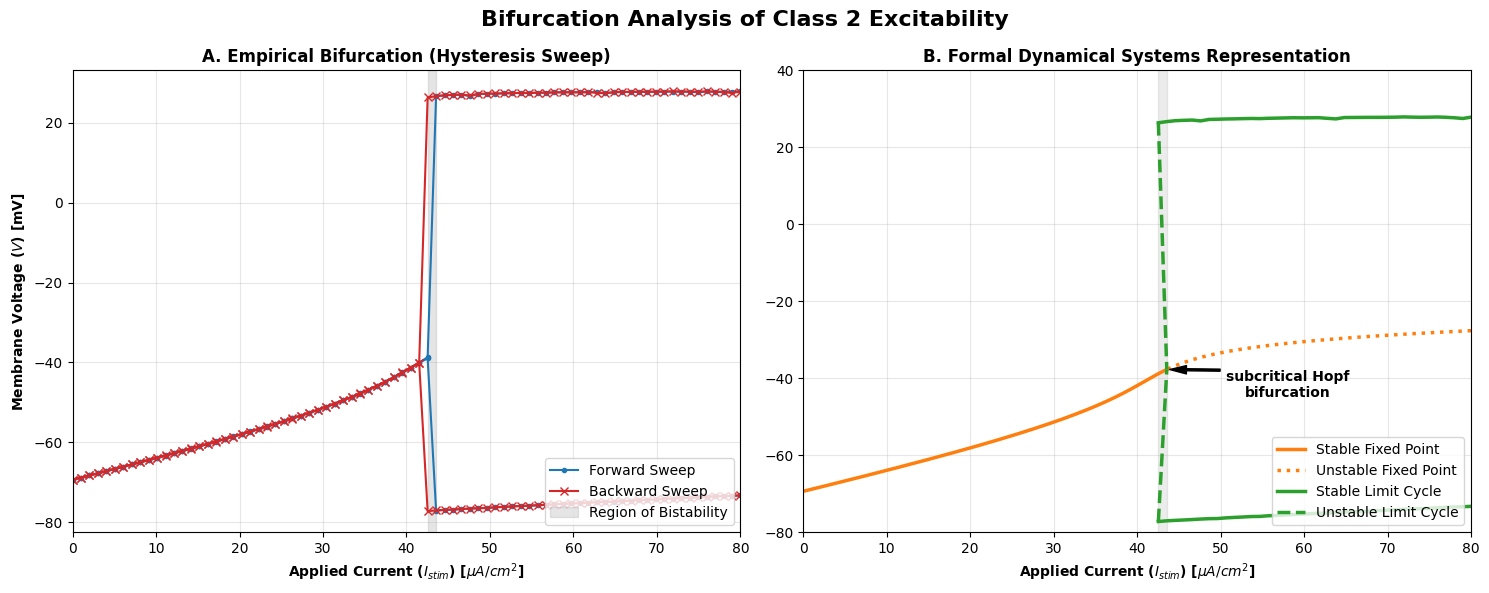

In [9]:
def class2_model(t, x, Istim):
    V, w = x
    C = 2; gfast = 20; ENa = 50; betam = -1.2; gammam = 18
    gslow = 20; EK = -100; betaw = -13; gammaw = 10
    gleak = 2; Eleak = -70; phiw = 0.15

    minf = 0.5 * (1 + np.tanh((V - betam) / gammam))
    winf = 0.5 * (1 + np.tanh((V - betaw) / gammaw))
    tauw = 1 / np.cosh((V - betaw) / (2 * gammaw))

    Ifast = gfast * minf * (V - ENa)
    Islow = gslow * w * (V - EK)
    Ileak = gleak * (V - Eleak)

    V_dot = (Istim - Ifast - Islow - Ileak) / C
    w_dot = phiw * (winf - w) / tauw
    return [V_dot, w_dot]

# sweep simulations
I_vals_forward = np.linspace(0, 80, 80)
I_vals_backward = np.flip(I_vals_forward)

V_max_fwd, V_min_fwd = [], []
V_max_bwd, V_min_bwd = [], []

sim_time = 200
transient = 150

# forward sweep
current_state = [-60.0, 0.01] 
for I in I_vals_forward:
    sol = scipy.integrate.solve_ivp(class2_model, [0, sim_time], current_state, args=(I,), dense_output=True)
    t_steady = np.linspace(transient, sim_time, 500)
    V_steady = sol.sol(t_steady)[0]
    V_max_fwd.append(np.max(V_steady))
    V_min_fwd.append(np.min(V_steady))
    current_state = [sol.y[0, -1], sol.y[1, -1]]

# backward sweep
current_state = [-20.0, 0.2] 
for I in I_vals_backward:
    sol = scipy.integrate.solve_ivp(class2_model, [0, sim_time], current_state, args=(I,), dense_output=True)
    t_steady = np.linspace(transient, sim_time, 500)
    V_steady = sol.sol(t_steady)[0]
    V_max_bwd.append(np.max(V_steady))
    V_min_bwd.append(np.min(V_steady))
    current_state = [sol.y[0, -1], sol.y[1, -1]]


V_max_fwd, V_min_fwd = np.array(V_max_fwd), np.array(V_min_fwd)
V_max_bwd, V_min_bwd = np.array(V_max_bwd), np.array(V_min_bwd)

# find empirical drop-off point from backward sweep
# "spike" is defined as an amplitude > 20 mV
bwd_spiking_mask = (V_max_bwd - V_min_bwd) > 20
last_spike_idx = np.where(bwd_spiking_mask)[0][-1]  # The lowest current before it stops spiking

drop_I = I_vals_backward[last_spike_idx]
V_max_drop = V_max_bwd[last_spike_idx]
V_min_drop = V_min_bwd[last_spike_idx]

# find empirical jump point from forward sweep
fwd_spiking_mask = (V_max_fwd - V_min_fwd) > 20
first_spike_idx = np.where(fwd_spiking_mask)[0][0]  # The first current where it starts spiking

hopf_I = I_vals_forward[first_spike_idx]

V_fp = np.linspace(-75, -20, 500)
minf_fp = 0.5 * (1 + np.tanh((V_fp - (-1.2)) / 18))
winf_fp = 0.5 * (1 + np.tanh((V_fp - (-13)) / 10))
I_fp = (20 * minf_fp * (V_fp - 50)) + (20 * winf_fp * (V_fp - (-100))) + (2 * (V_fp - (-70)))

stable_fp_mask = I_fp <= hopf_I
unstable_fp_mask = I_fp > hopf_I

idx_hopf = np.argmin(np.abs(I_fp - hopf_I))
V_hopf_val = V_fp[idx_hopf]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# panel A: sweep results
ax1.plot(I_vals_forward, V_max_fwd, '.-', color='tab:blue', label='Forward Sweep')
ax1.plot(I_vals_forward, V_min_fwd, '.-', color='tab:blue')
ax1.plot(I_vals_backward, V_max_bwd, 'x-', color='tab:red', label='Backward Sweep')
ax1.plot(I_vals_backward, V_min_bwd, 'x-', color='tab:red')

ax1.axvspan(drop_I, hopf_I, color='gray', alpha=0.2, label='Region of Bistability')

ax1.set_title('A. Empirical Bifurcation (Hysteresis Sweep)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Applied Current ($I_{stim}$) [$\mu A / cm^2$]', fontweight='bold')
ax1.set_ylabel('Membrane Voltage ($V$) [mV]', fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend(loc='lower right')
ax1.set_xlim(0, 80)

# panel B: bifuucation diagram
ax2.plot(I_fp[stable_fp_mask], V_fp[stable_fp_mask], color='tab:orange', linewidth=2.5, label='Stable Fixed Point')
ax2.plot(I_fp[unstable_fp_mask], V_fp[unstable_fp_mask], color='tab:orange', linestyle=':', linewidth=2.5, label='Unstable Fixed Point')

ax2.plot(I_vals_backward[bwd_spiking_mask], V_max_bwd[bwd_spiking_mask], color='tab:green', linewidth=2.5, label='Stable Limit Cycle')
ax2.plot(I_vals_backward[bwd_spiking_mask], V_min_bwd[bwd_spiking_mask], color='tab:green', linewidth=2.5)

unstable_I = [drop_I, hopf_I]
unstable_V_max = [V_max_drop, V_hopf_val]  
unstable_V_min = [V_min_drop, V_hopf_val] 

ax2.plot(unstable_I, unstable_V_max, color='tab:green', linestyle='--', linewidth=2.5, zorder=10, label='Unstable Limit Cycle')
ax2.plot(unstable_I, unstable_V_min, color='tab:green', linestyle='--', linewidth=2.5, zorder=10)

ax2.annotate('subcritical Hopf\nbifurcation', xy=(hopf_I, V_hopf_val), xytext=(58, -45),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
             fontsize=10, fontweight='bold', ha='center')

ax2.axvspan(drop_I, hopf_I, color='gray', alpha=0.15)

ax2.set_title('B. Formal Dynamical Systems Representation', fontweight='bold', fontsize=12)
ax2.set_xlabel('Applied Current ($I_{stim}$) [$\mu A / cm^2$]', fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend(loc='lower right')
ax2.set_xlim(0, 80)
ax2.set_ylim(-80, 40)

plt.suptitle('Bifurcation Analysis of Class 2 Excitability', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()